In [2]:
# Imports essenciais no projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import warnings

# Suprimindo FutureWarnings
warnings.simplefilter(action='ignore', category = FutureWarning)

# Importando o dataset
df = pd.read_csv('application_train.csv')

dfaux = pd.read_csv("credit_card_balance.csv")
dfaux = pd.merge(df, dfaux, how="inner", on="SK_ID_CURR").drop_duplicates()

dfaux2 = pd.read_csv("previous_application.csv")
dfaux2 = pd.merge(df, dfaux2, how="inner", on="SK_ID_CURR").drop_duplicates()

FileNotFoundError: [Errno 2] No such file or directory: 'application_train.csv'

In [301]:
# Mostrando as 5 primeiras linhas do dataset
df.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [302]:
# Contagem dos tipos de dados no dataset
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [303]:
# Contagem de valores únicos, nas colunas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} valores únicos\n")

NAME_CONTRACT_TYPE: 2 valores únicos

CODE_GENDER: 3 valores únicos

FLAG_OWN_CAR: 2 valores únicos

FLAG_OWN_REALTY: 2 valores únicos

NAME_TYPE_SUITE: 7 valores únicos

NAME_INCOME_TYPE: 8 valores únicos

NAME_EDUCATION_TYPE: 5 valores únicos

NAME_FAMILY_STATUS: 6 valores únicos

NAME_HOUSING_TYPE: 6 valores únicos

OCCUPATION_TYPE: 18 valores únicos

WEEKDAY_APPR_PROCESS_START: 7 valores únicos

ORGANIZATION_TYPE: 58 valores únicos

FONDKAPREMONT_MODE: 4 valores únicos

HOUSETYPE_MODE: 3 valores únicos

WALLSMATERIAL_MODE: 7 valores únicos

EMERGENCYSTATE_MODE: 2 valores únicos



In [304]:
# Estatísticas descritivas para colunas numéricas do dataset
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [305]:
# Exibindo o formato do dataset
tupla_shape = df.shape
print(f"Linhas: {tupla_shape[0]} || Colunas: {tupla_shape[1]}")

Linhas: 307511 || Colunas: 122


# Tratamento Inicial dos Dados

In [306]:
from datetime import datetime, timedelta

# Data atual
current_date = datetime(2018, 7, 1)

novas_colunas = ["BIRTH_DATE", "EMPLOYEMENT_DATE", "REGISTRATION_DATE","ID_REG_DATE"]
colunas_antes = ["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH"]

# Criando novas colunas categóricas
for idx in range(0,4,1):
    df[novas_colunas[idx]] = df[colunas_antes[idx]].apply(lambda x : str(current_date + timedelta(days = x)))
    df[novas_colunas[idx]] = df[novas_colunas[idx]].str.split(' ').str[0]
    df[novas_colunas[idx]] = pd.to_datetime(df[novas_colunas[idx]], format = "%Y-%m-%d", errors = "coerce")
    
# Convert DAYS_BIRTH to years (assuming it's negative days from today)
df['AGE'] = abs(df['DAYS_BIRTH'] // 365) 

In [307]:
dfaux2["MONTH_YEAR"] = dfaux2["DAYS_DECISION"].apply(lambda x: str(current_date + timedelta(days=x)))
dfaux2["MONTH_YEAR"] = pd.to_datetime(dfaux2["MONTH_YEAR"], errors="coerce")

dfaux2["YEAR_PREVIOUS"] = dfaux2["MONTH_YEAR"].dt.year
dfaux2["MONTH_PREVIOUS"] = dfaux2["MONTH_YEAR"].dt.month

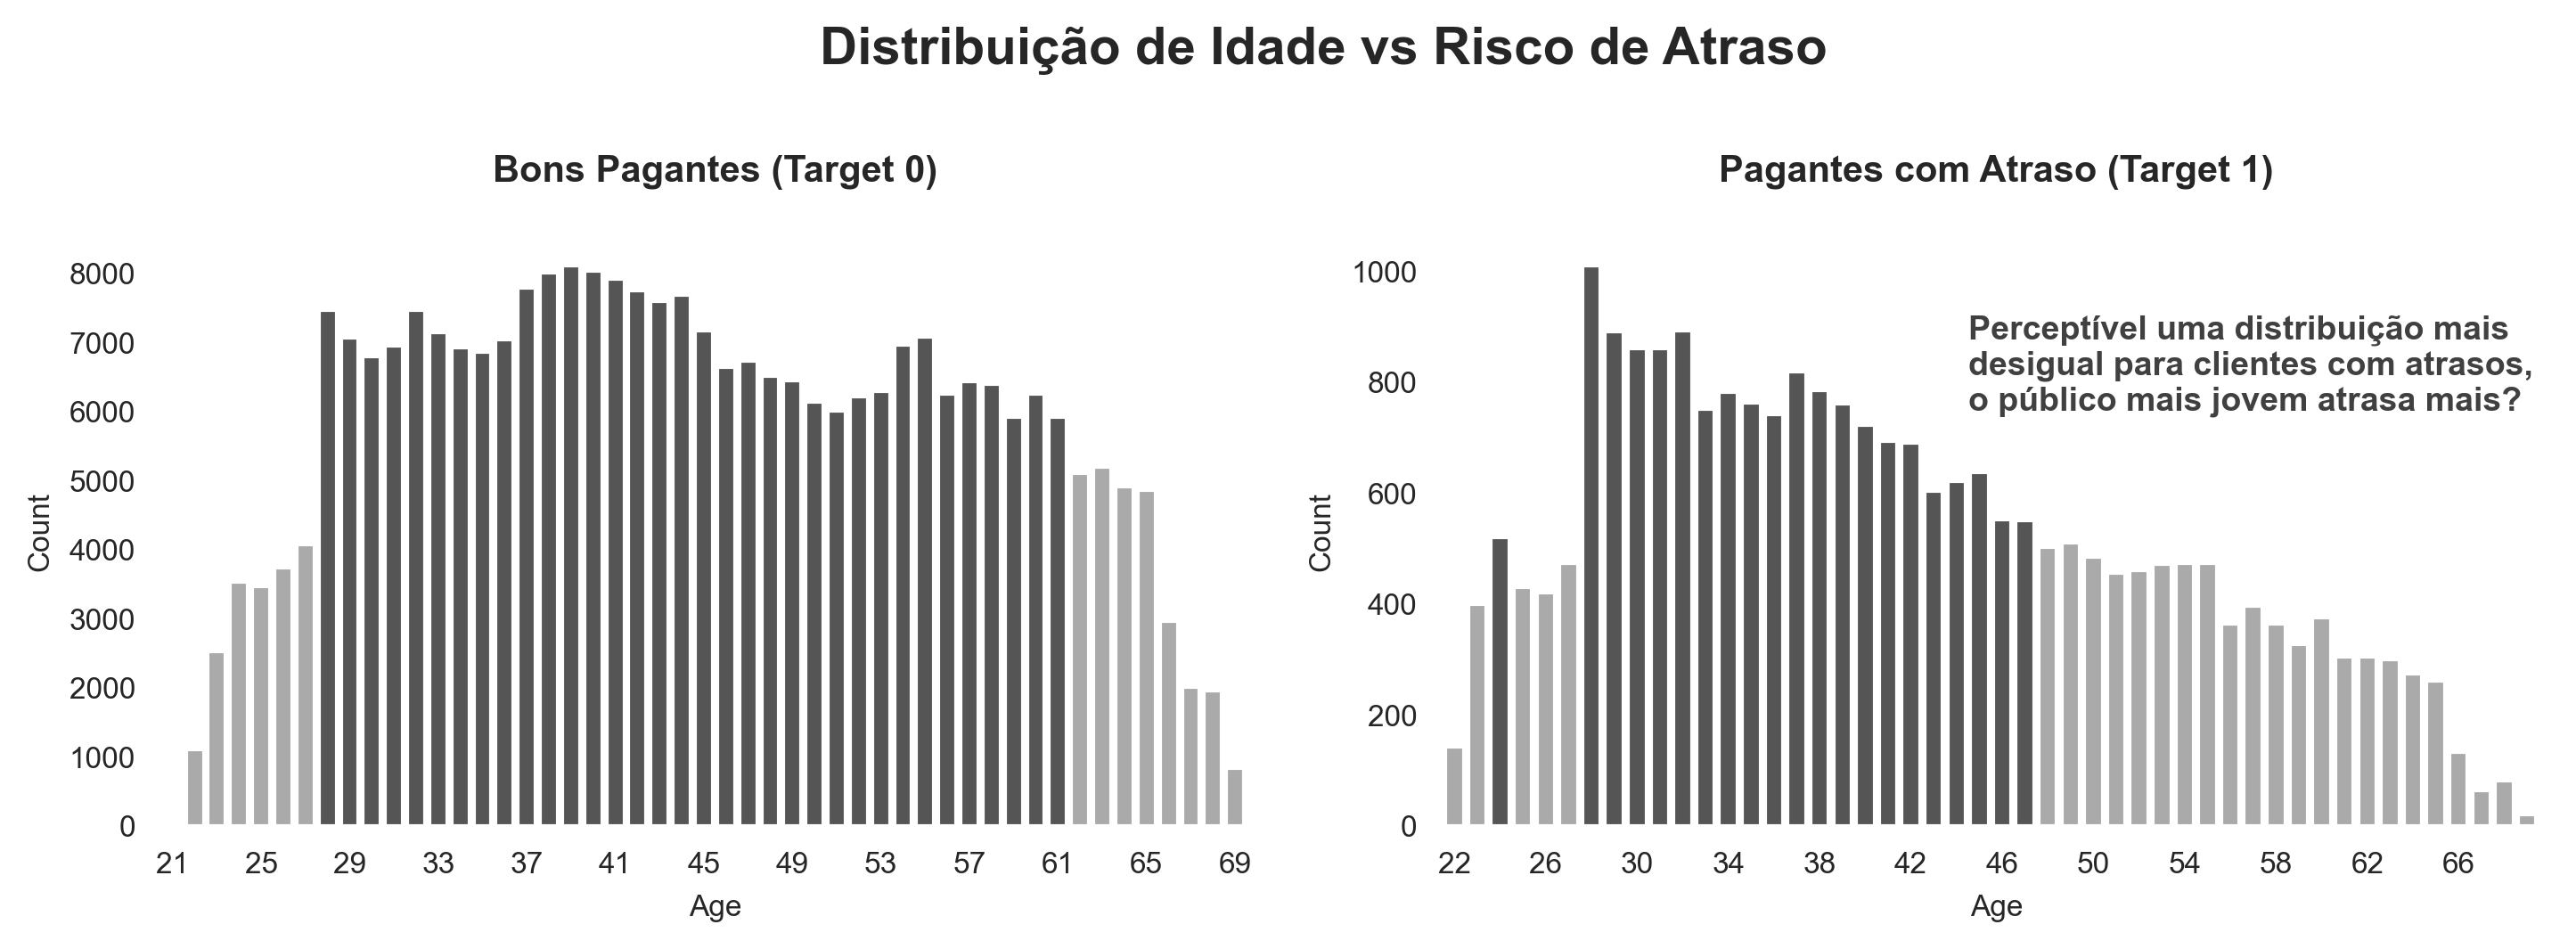

In [308]:
fig, ax = plt.subplots(1, 2, dpi=300, figsize=(10, 3.5))
titles = ['Bons Pagantes (Target 0)', 'Pagantes com Atraso (Target 1)']

for idx in range(2):
    # Lógica principal do barplot e das cores
    age_counts = df[df["TARGET"] == idx]["AGE"].value_counts().sort_index()
    cores = ['#555555' if count > age_counts.mean() else '#aaaaaa' for count in age_counts]
    sns.barplot(x=age_counts.index, y=age_counts.values, ax=ax[idx], palette = cores)
    
    # Customizando o plot
    ax[idx].set_title(titles[idx], fontsize = 10, pad = 15, fontweight='bold')
    ax[idx].set_xlabel("Age", fontsize = 8)
    ax[idx].set_ylabel("Count", fontsize = 8)
    ax[idx].set_xticks(range(0, 50, 4), minor = False)
    ax[idx].tick_params(axis = "both", which = "major", labelsize = 8)
    
    # Eliminando as espinhas
    for spine in ax[idx].spines.values():
        spine.set_visible(False)
        
    # Aplicando um texto explicativo no segundo plot
    if idx == 1:
        ax[idx].text(22.5, 750, 
             "Perceptível uma distribuição mais\ndesigual para clientes com atrasos,\no público mais jovem atrasa mais?",
             fontsize=9,
             fontfamily='sans-serif',
             fontweight='bold',
             color='#404040')
        
    ax[idx].grid(False)
    
fig.suptitle('Distribuição de Idade vs Risco de Atraso', fontsize=14, fontweight='bold', y=1)

plt.tight_layout()
plt.show()

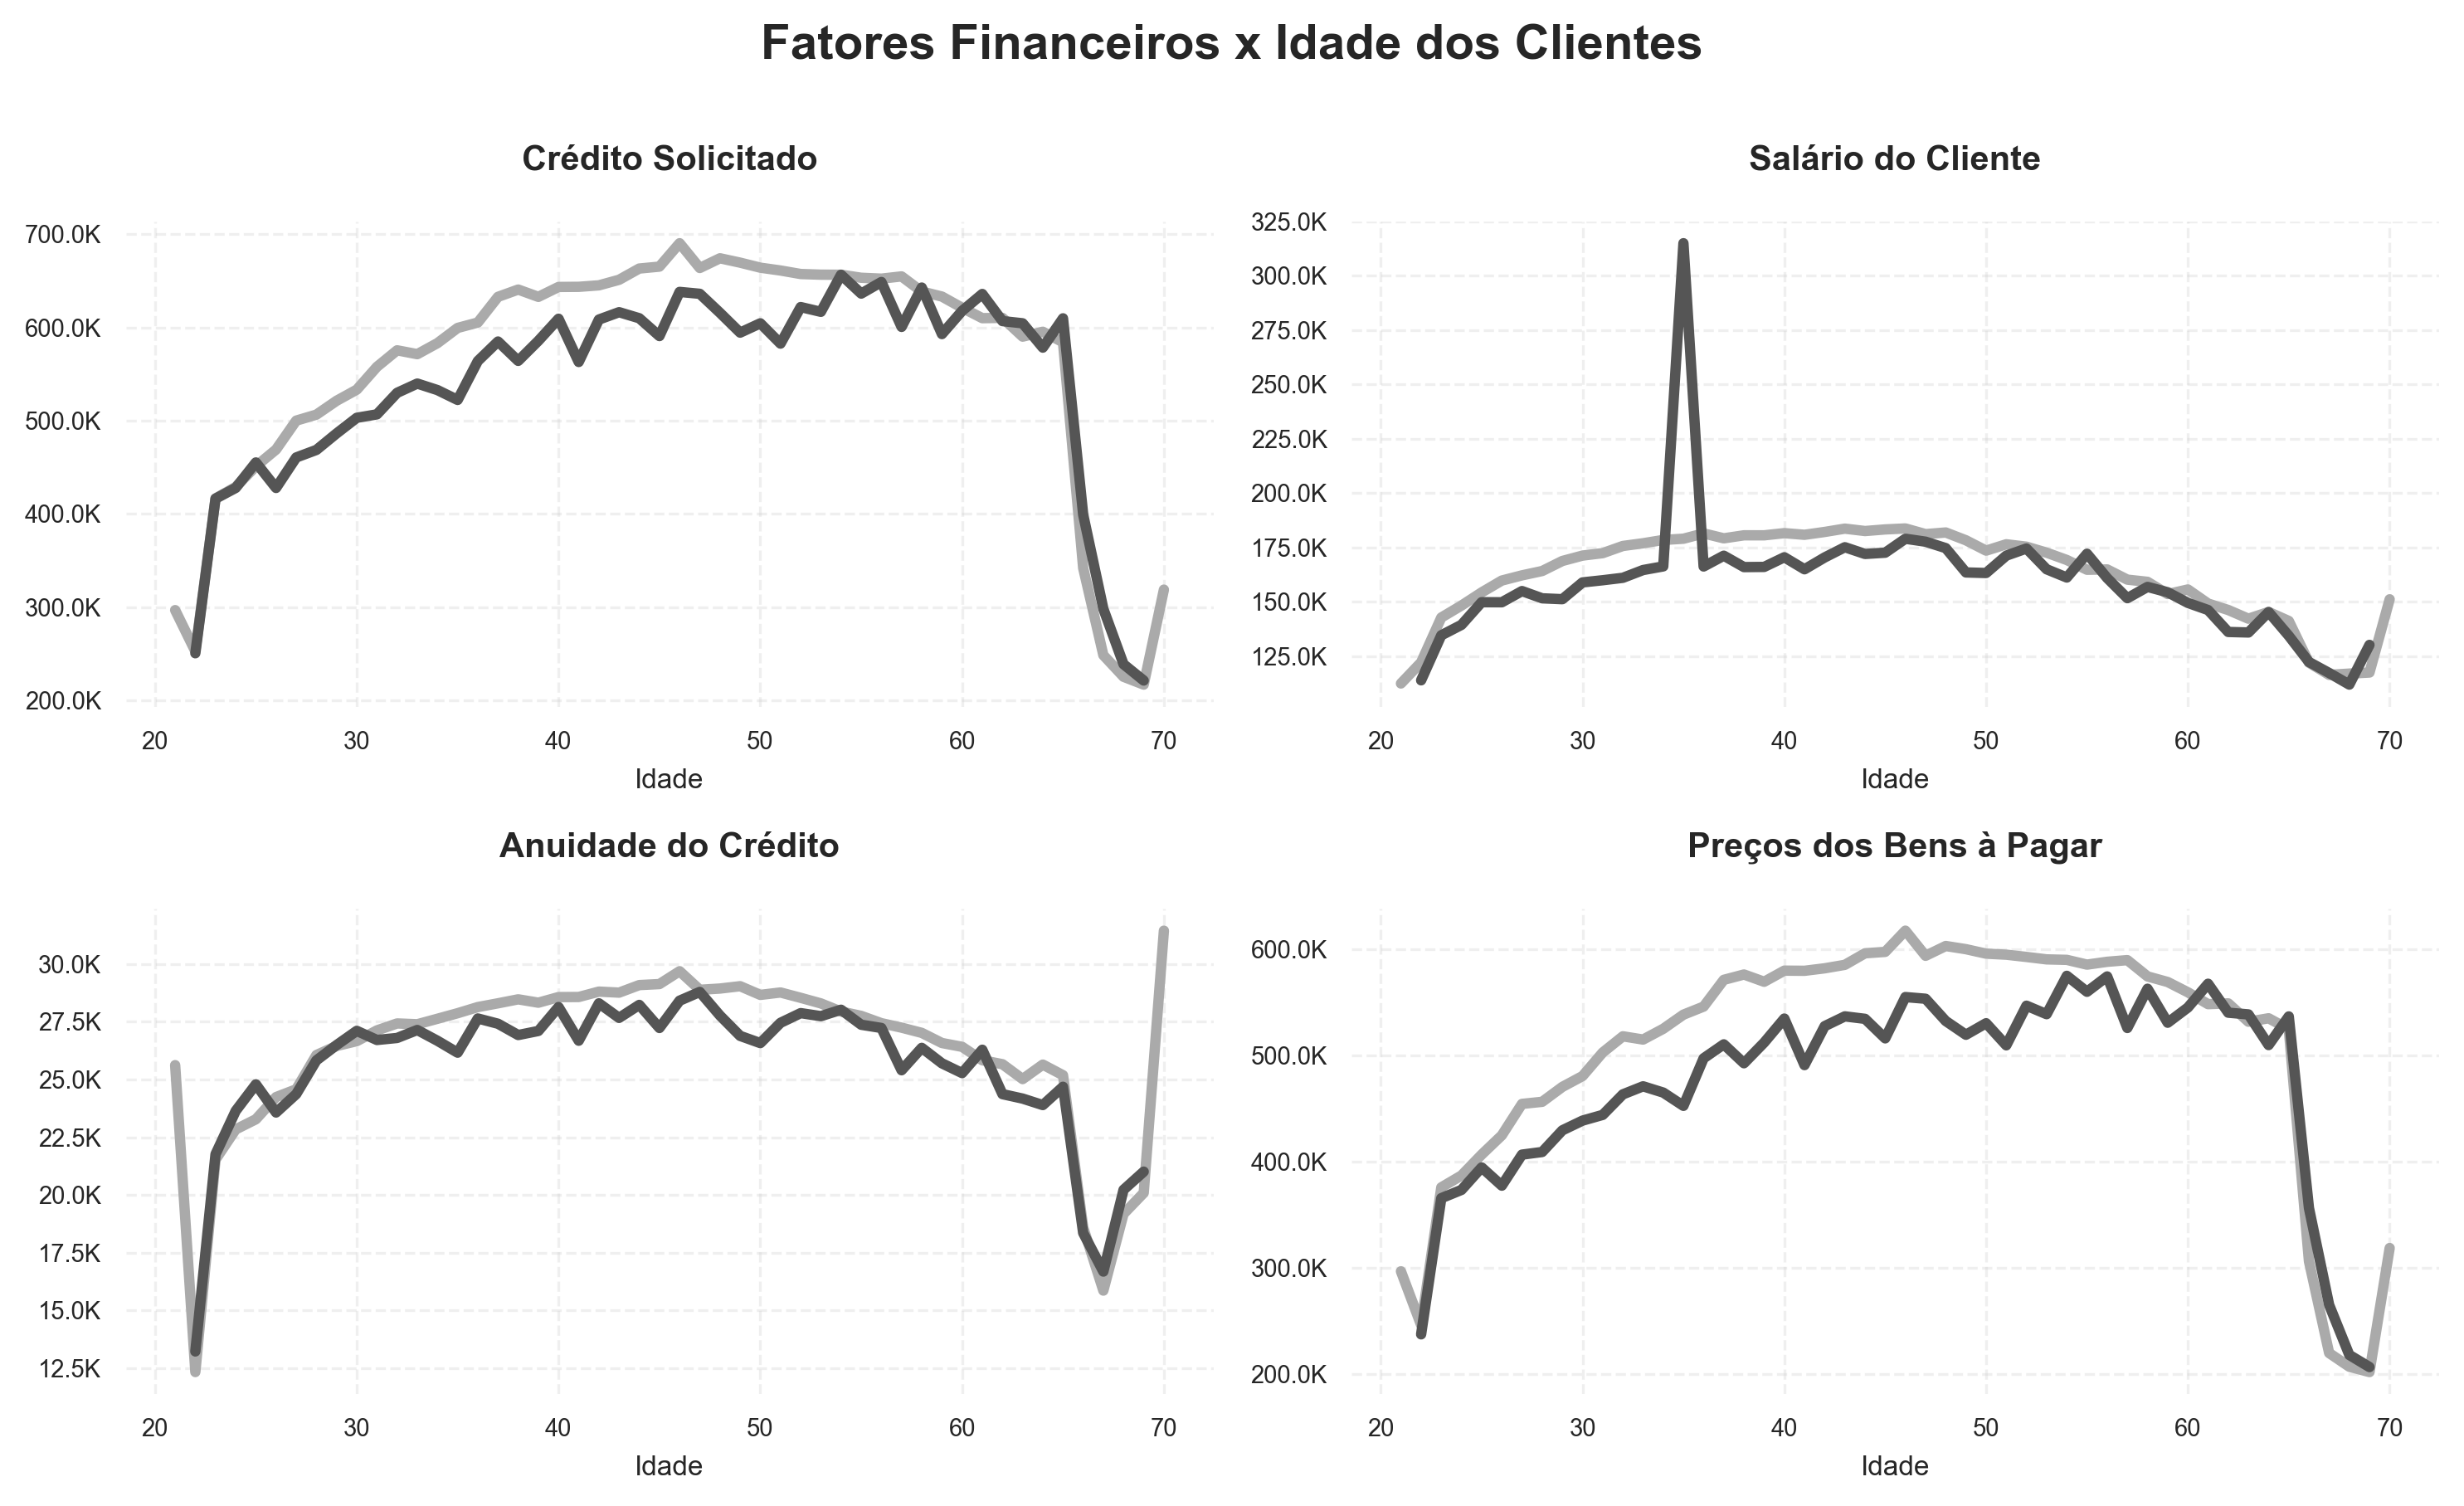

In [309]:
colunas = ["AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
titulos = ["Crédito Solicitado", "Salário do Cliente", "Anuidade do Crédito", "Preços dos Bens à Pagar"]
fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi=300)  # Adjusted figsize for better visibility

for idx, col in enumerate(colunas):
    ax = axs[idx // 2, idx % 2]
    paletta_customizada = {1: "#555555", 0: "#aaaaaa"} 
    sns.lineplot(data=df, linewidth=3, x='AGE', y=col, hue="TARGET", palette = paletta_customizada, errorbar=None, ax=ax)
    
    # Set labels and titles for each subplot
    ax.set_title(titulos[idx], fontsize = 10, pad = 15, fontweight='bold')
    ax.set_xlabel('Idade', fontsize = 8)
    ax.set_ylabel("")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{float(x/1e3)}K'))
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.legend().remove()
    
    # Remove spines and legend for a cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)
 
    # Calculando a média dos valores por idade para TARGET 1 e TARGET 0
    aux1 = df[df["TARGET"] == 1].groupby("AGE")[col].mean().reset_index(name=f"{col}_TARGET_1")
    aux2 = df[df["TARGET"] == 0].groupby("AGE")[col].mean().reset_index(name=f"{col}_TARGET_0")
    res = pd.merge(aux1, aux2, on="AGE", how="inner")
    
    # Filtrando onde a diferença entre os valores médios é maior que 50.000
    res['Diff'] = abs(res[f"{col}_TARGET_1"] - res[f"{col}_TARGET_0"])
    res = res[res['Diff'] > 75000]
    
fig.suptitle("Fatores Financeiros x Idade dos Clientes", fontsize=14, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

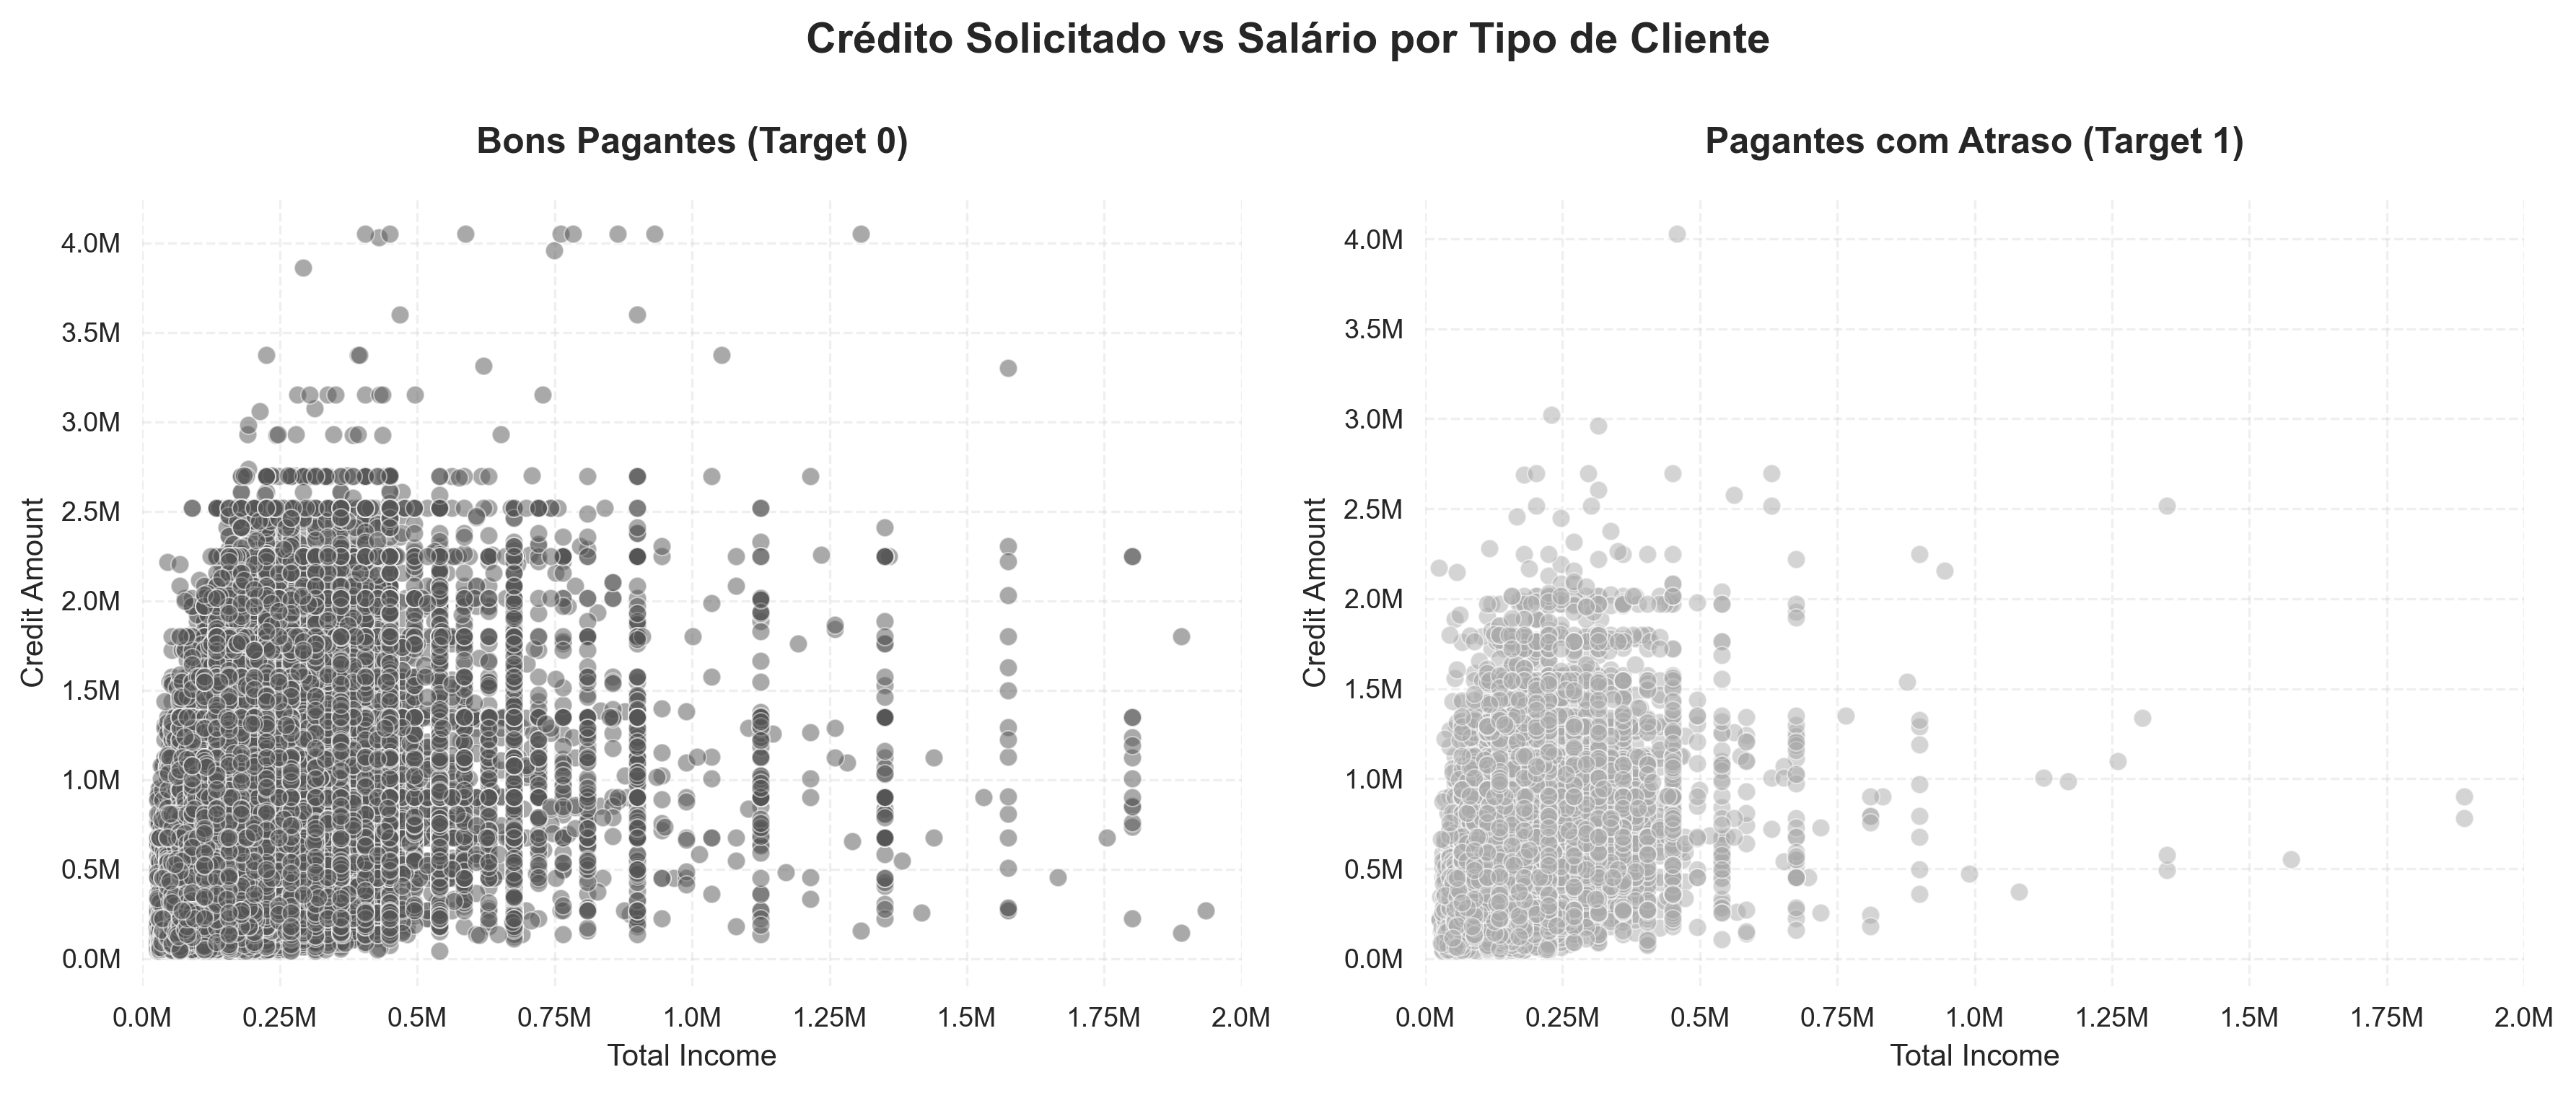

In [310]:
# Criando a figura
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Definindo cores mais apropriadas para cada target
colors = ['#555555', '#aaaaaa']  # Verde para 0 (bom pagador), Vermelho para 1 (mau pagador)
titles = ['Bons Pagantes (Target 0)', 'Pagantes com Atraso (Target 1)']

# Plotando os dados
for idx in range(2):
    aux = df[df["TARGET"] == idx]
    
    # Scatter plot com alpha para melhor visualização de pontos sobrepostos
    sns.scatterplot(data = aux, x = "AMT_INCOME_TOTAL", y = "AMT_CREDIT", color = colors[idx], alpha = 0.5, ax = axs[idx])
    
    # Removendo as espinhas do gráfico
    for spine in axs[idx].spines.values():
        spine.set_visible(False)
    
    # Customizando o plot
    axs[idx].set_title(titles[idx], fontsize=12, pad=15, fontweight='bold')
    axs[idx].set_xlabel("Total Income", fontsize=10)
    axs[idx].set_ylabel("Credit Amount", fontsize=10)
    
    # Formatando os ticks
    axs[idx].tick_params(axis='both', which='major', labelsize=9)
    
    # Definindo limites dos eixos
    axs[idx].set_xlim(0, 0.2e7)
    axs[idx].grid(True, linestyle='--', alpha=0.3)
    
    # Formatando os valores dos eixos para melhor legibilidade
    axs[idx].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{float(x/1e6)}M'))
    axs[idx].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{float(x/1e6)}M'))

# Adicionando um título global
fig.suptitle('Crédito Solicitado vs Salário por Tipo de Cliente', fontsize=14, fontweight='bold', y=1)

# Ajustando o layout
plt.tight_layout()
plt.show()

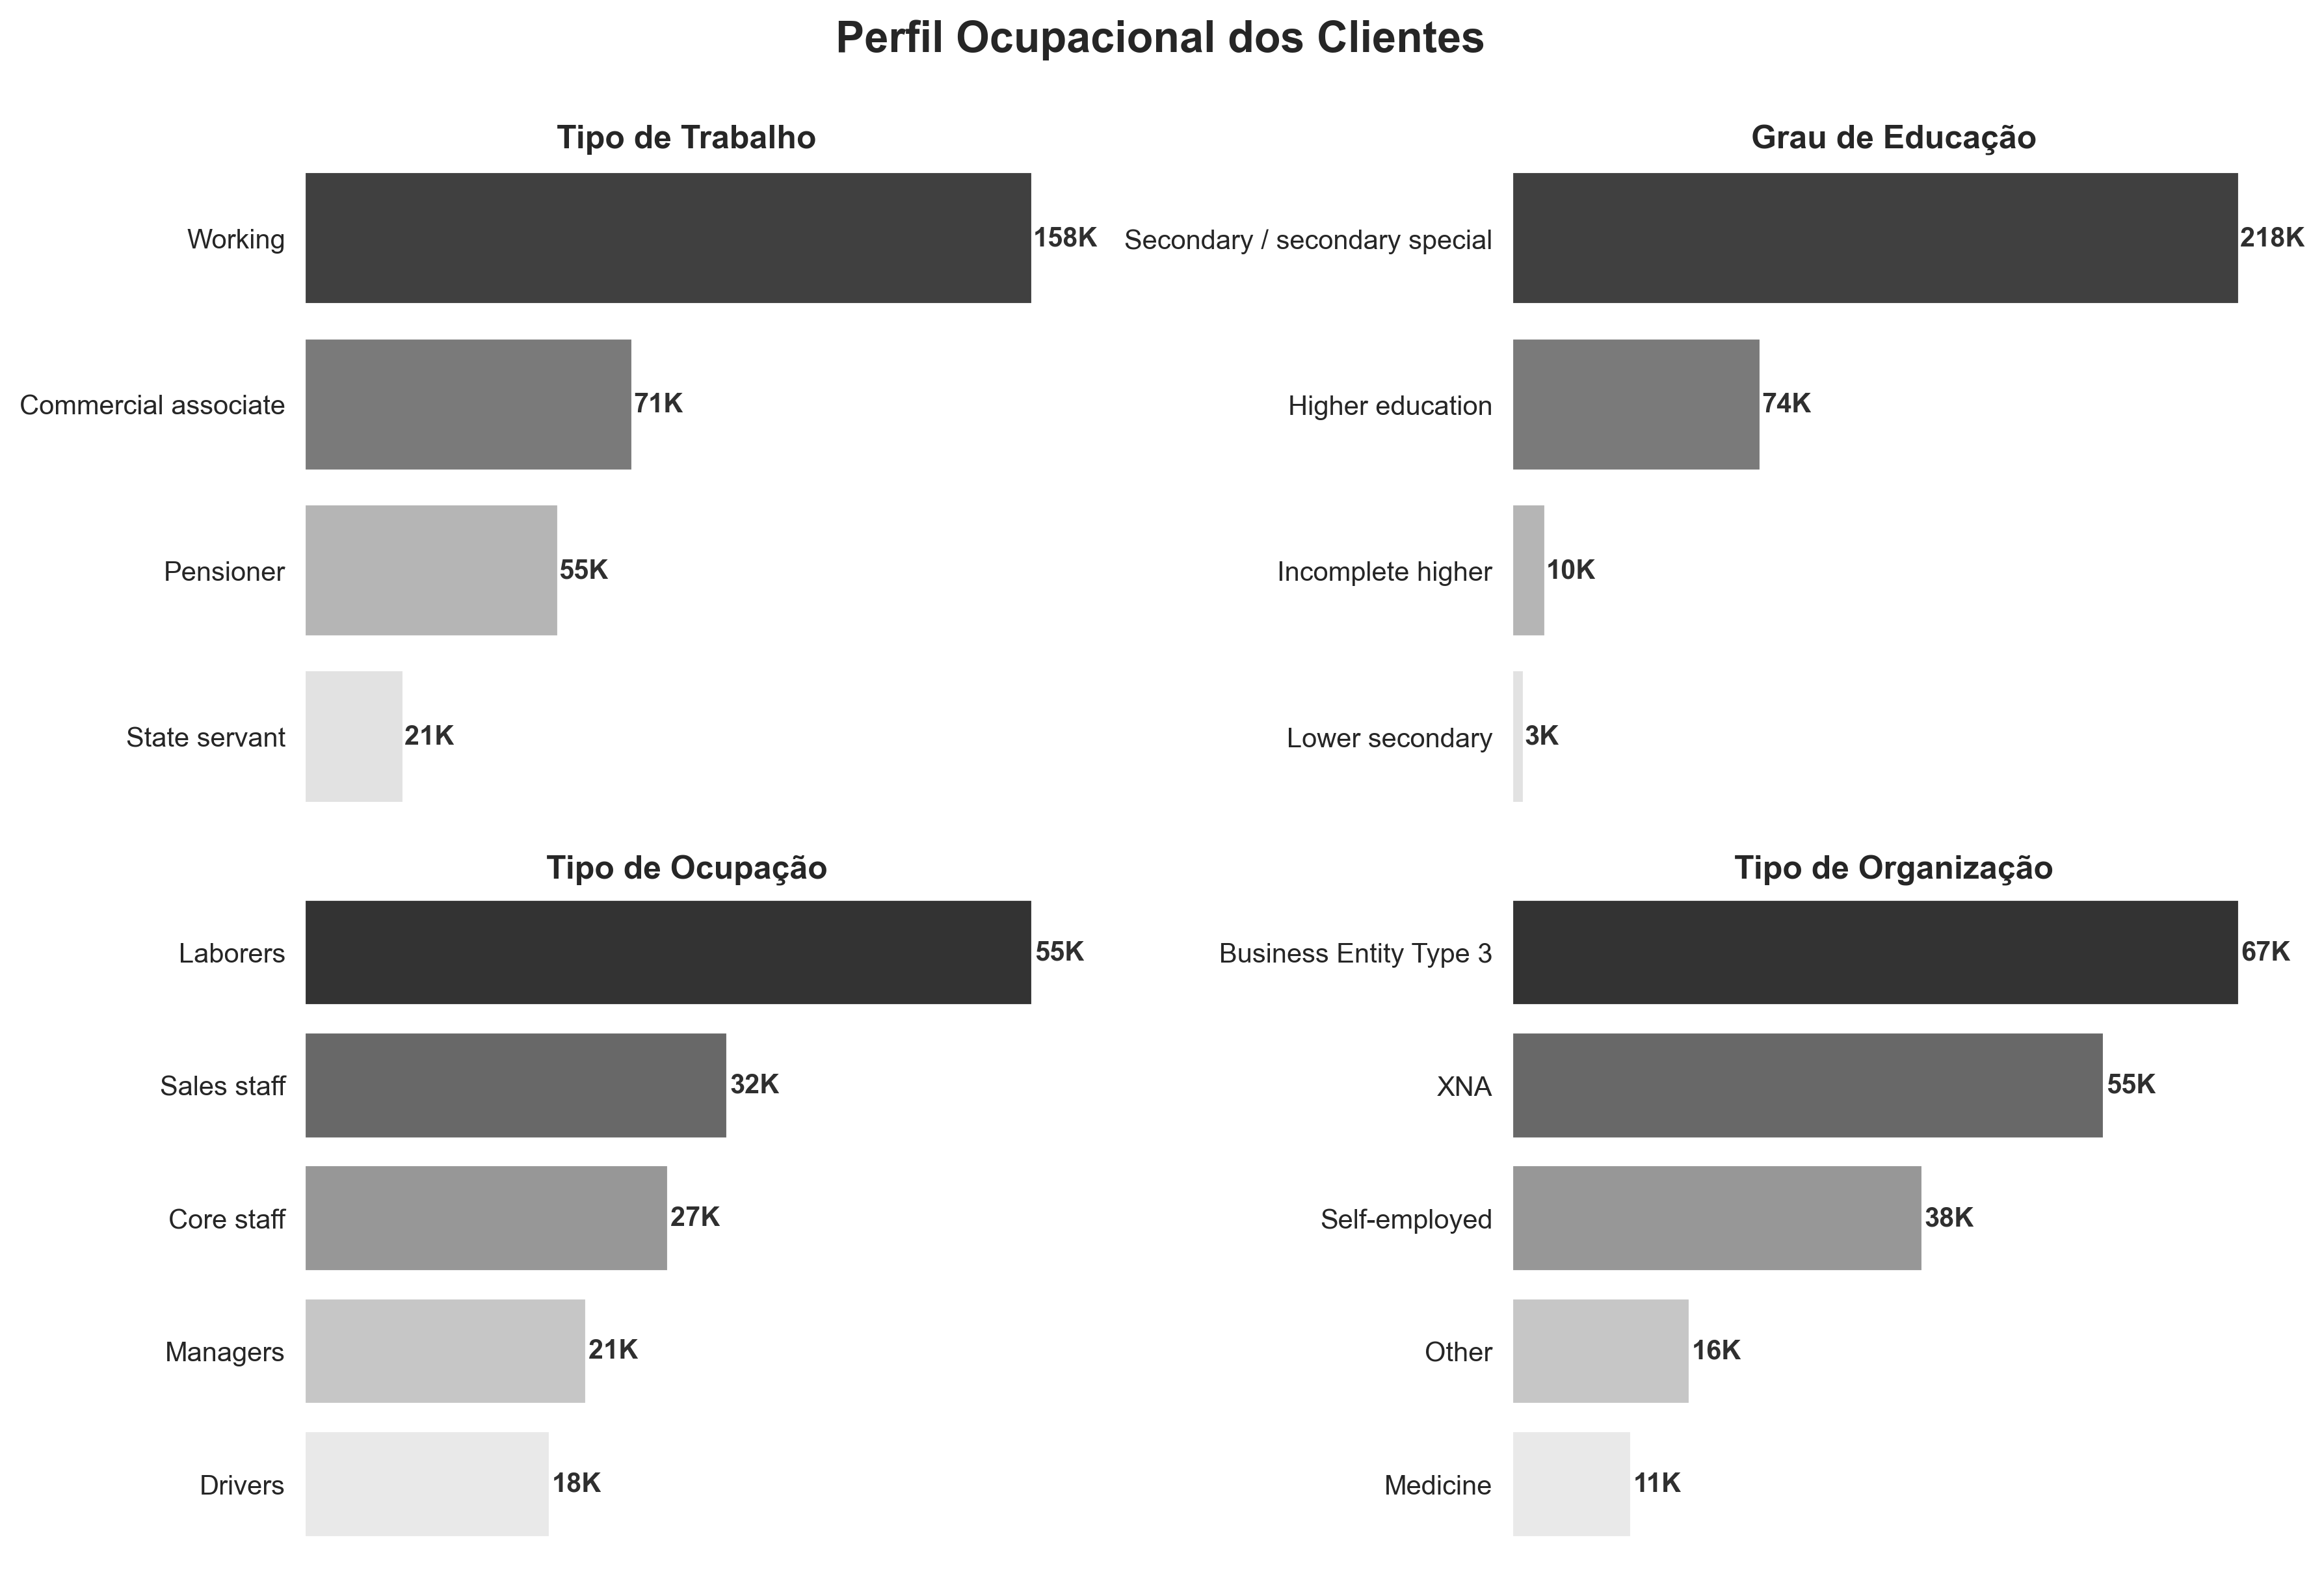

In [311]:
colunas = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE"]
titulos = ["Tipo de Trabalho", "Grau de Educação", "Tipo de Ocupação", "Tipo de Organização"]

fig, axs = plt.subplots(2, 2, figsize=(12, 8), dpi=300)
axs = axs.flatten()

for idx, col in enumerate(colunas):
    # Lógica Principal do Barplot
    counts = df[col].value_counts().sort_index().sort_values(ascending=False).head(6)
    q15 = np.percentile(counts, 15)
    counts = counts[(counts > q15) & (counts > 1000)]
    sns.barplot(y=counts.index, x=counts.values, orient="h", palette=sns.color_palette("Greys_r", n_colors=len(counts)), ax=axs[idx])
    
    # Melhorando o design
    axs[idx].set_ylabel("")
    axs[idx].set_title(titulos[idx], fontsize=12, pad=15, fontweight='bold', y = 0.95)
    axs[idx].grid(False)
    axs[idx].set_xticks([])
    
    for spine in axs[idx].spines.values():
        spine.set_visible(False)
        
    for i, v in enumerate(counts.values):
        axs[idx].text(v + 150, i, f'{int(v/1e3)}K', color='#2F2F2F', va='center', fontweight='bold', fontsize=10)
        
    axs[idx].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{float(x/1e3)}K'))

plt.suptitle('Perfil Ocupacional dos Clientes', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

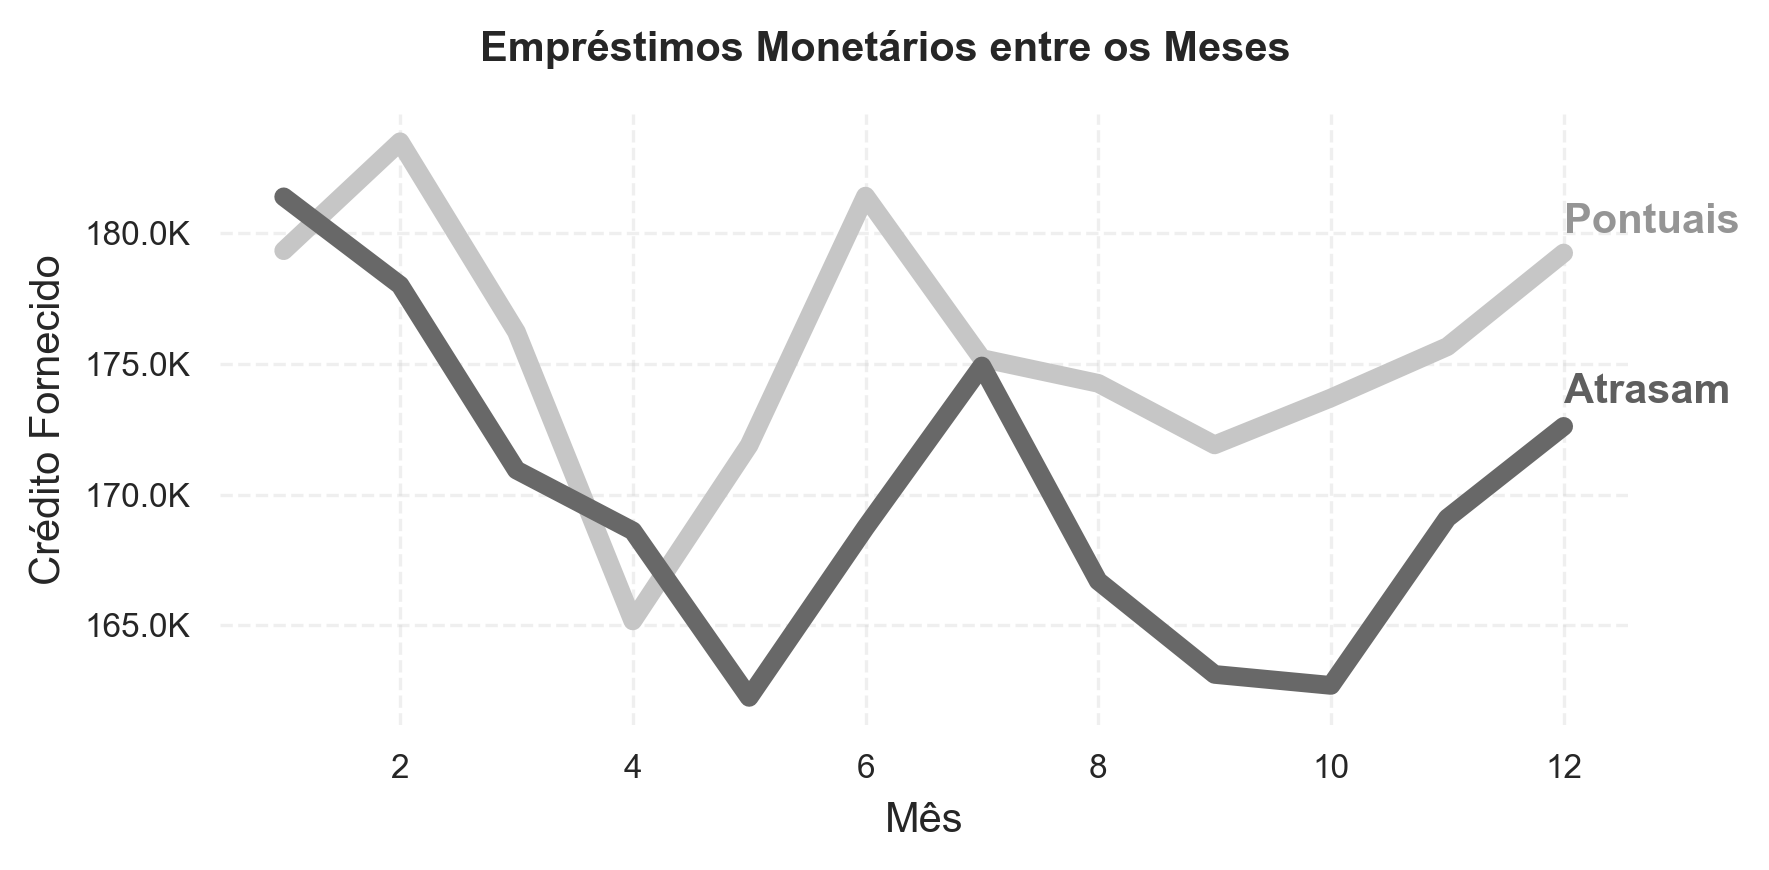

In [332]:
aux1 = dfaux2.groupby(["MONTH_PREVIOUS", "TARGET"])["AMT_APPLICATION"].mean().reset_index()

plt.figure(figsize = (6,3), dpi = 300)
sns.lineplot(data=aux1, x="MONTH_PREVIOUS", y="AMT_APPLICATION", hue = "TARGET", palette = "Greys", linewidth = 4.5)

for spine in plt.gca().spines.values():
    spine.set_visible(False)
    
plt.xlabel("Mês", fontsize = 10)
plt.ylabel("Crédito Fornecido", fontsize = 10)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{float(x/1e3)}K'))
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend().remove()

plt.text(12, 173500, "Atrasam", color=plt.cm.Greys(0.7), fontweight='bold')
plt.text(12, 180000, "Pontuais", color=plt.cm.Greys(0.5), fontweight='bold')

plt.suptitle("Empréstimos Monetários entre os Meses", fontsize=10, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

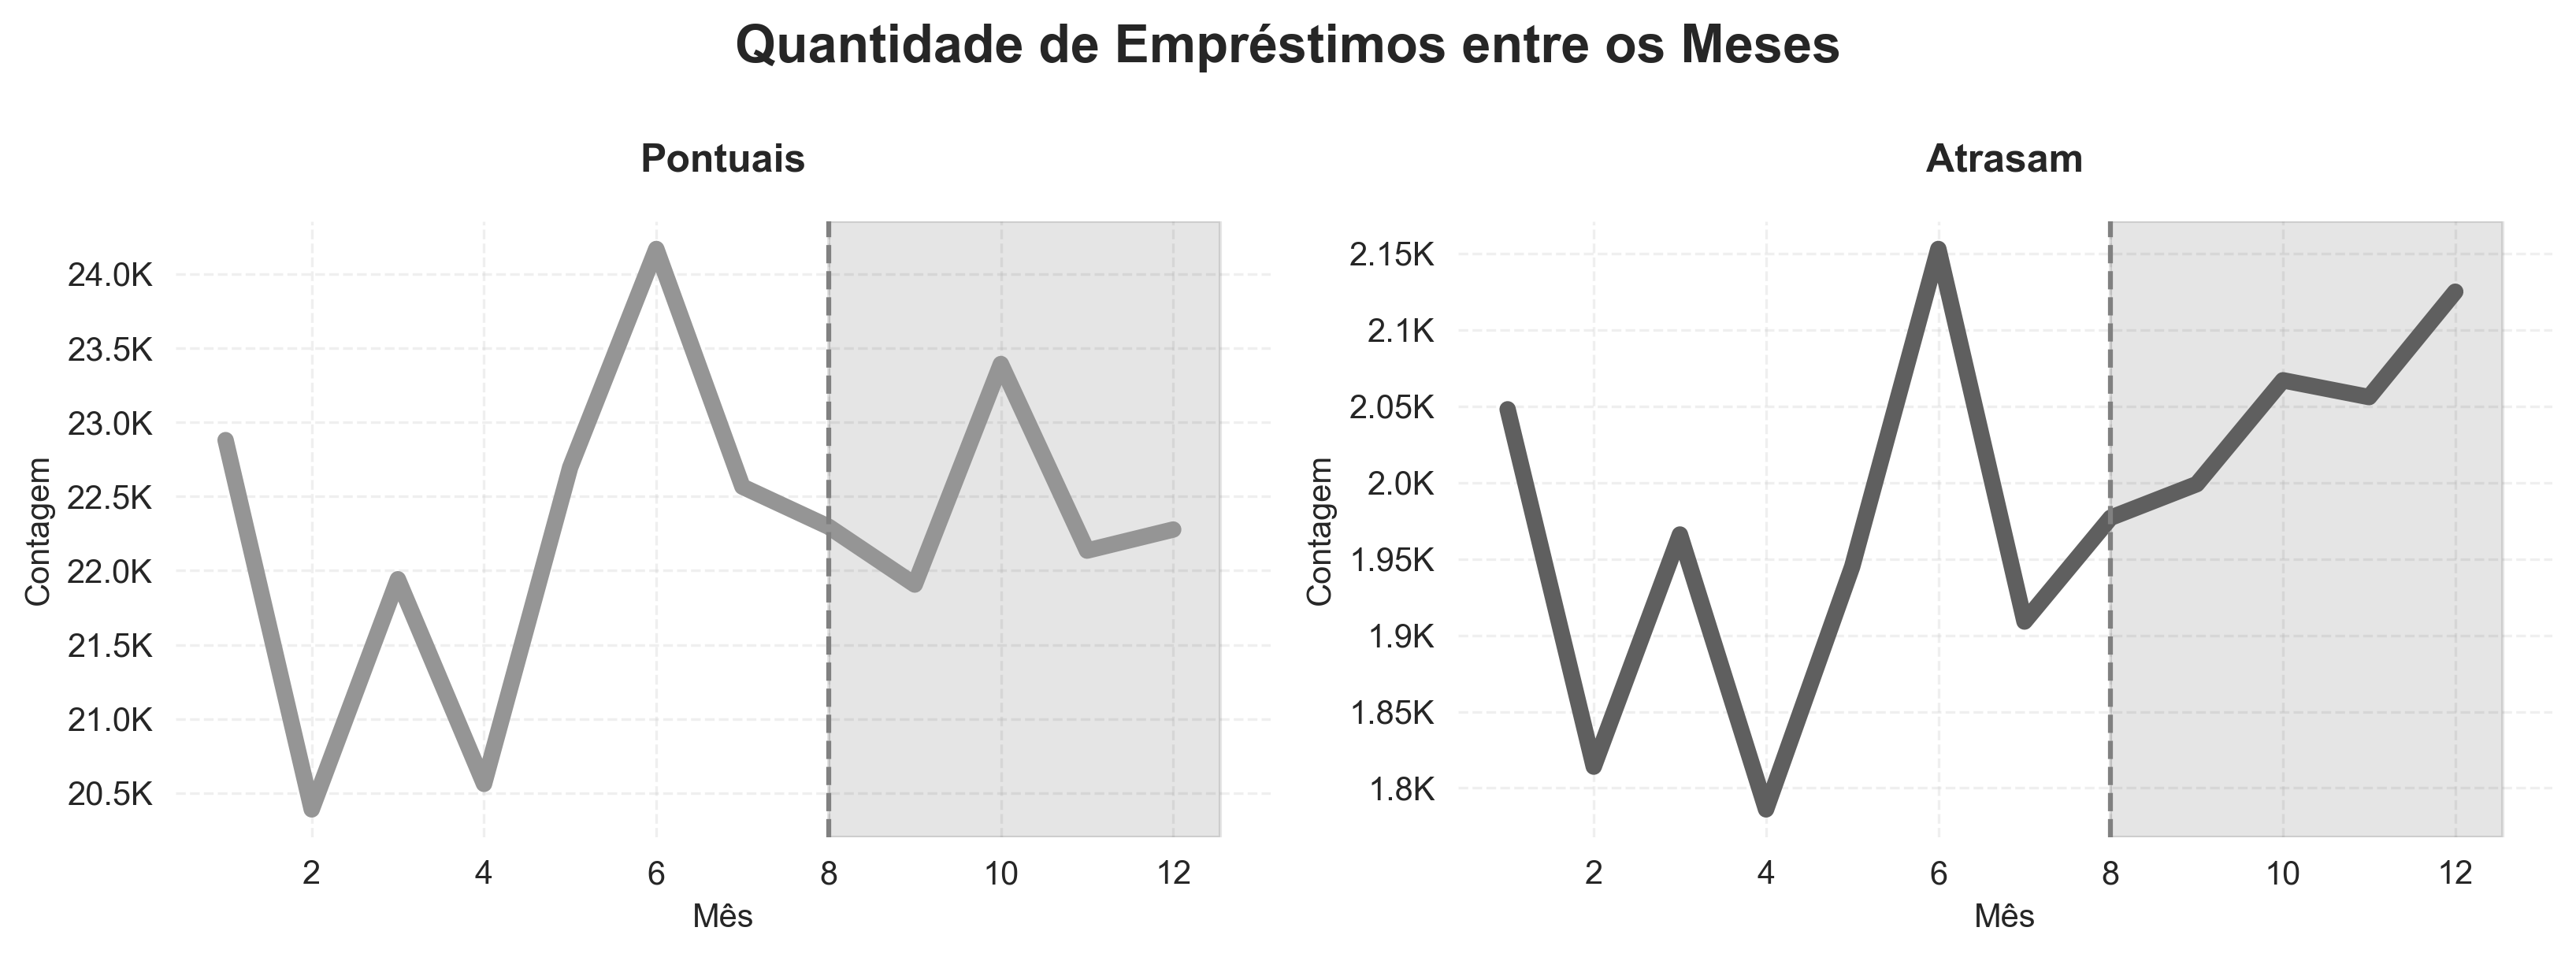

In [333]:
aux2 = dfaux2.drop_duplicates(subset = "SK_ID_CURR").groupby(["MONTH_PREVIOUS", "TARGET"])["AMT_APPLICATION"].count().reset_index()

# Criar a figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi=300)

# Plot para TARGET = 0
target_0 = aux2[aux2['TARGET'] == 0]
sns.lineplot(data = target_0, x = 'MONTH_PREVIOUS', y = 'AMT_APPLICATION',ax = ax1,linewidth = 5, color = plt.cm.Greys(0.5))
ax1.axvline(x = 8, linestyle = "--", color = 'grey')
ax1.axvspan(8, ax1.get_xlim()[1], color='black', alpha=0.1)

# Plot para TARGET = 1
target_1 = aux2[aux2['TARGET'] == 1]
sns.lineplot(data = target_1, x = 'MONTH_PREVIOUS', y = 'AMT_APPLICATION', ax = ax2, linewidth = 5, color = plt.cm.Greys(0.7))
ax2.axvline(x = 8, linestyle = "--", color = 'grey')
ax2.axvspan(8, ax2.get_xlim()[1], color = "black", alpha = 0.1)

# Configurações gerais para ambos os subplots
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    ax.set_xlabel("Mês", fontsize=10)
    ax.set_ylabel("Contagem", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{float(x/1e3)}K'))
    ax.grid(True, linestyle='--', alpha=0.3)

# Títulos específicos
ax1.set_title('Pontuais', fontsize=12, pad=15, fontweight='bold')
ax2.set_title('Atrasam', fontsize=12, pad=15, fontweight='bold')

# Título geral
plt.suptitle("Quantidade de Empréstimos entre os Meses", fontsize=16, fontweight='bold',y=1)

plt.tight_layout()
plt.show()

# PENSAMENTOS !!!!!!

<Axes: xlabel='None', ylabel='AMT_APPLICATION'>

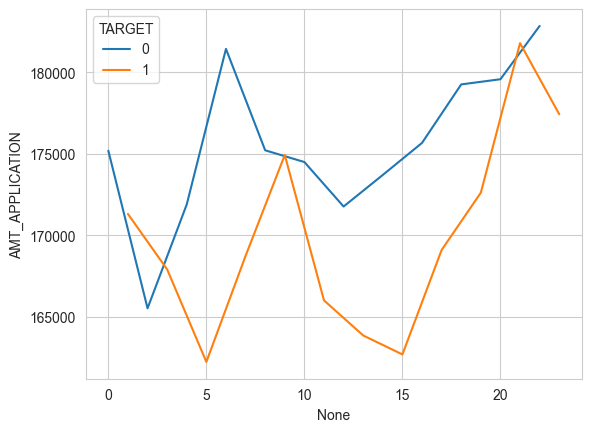

In [314]:
sns.lineplot(aux3, x = aux3.index, y = "AMT_APPLICATION", hue = "TARGET")